
  FUTURE INTERNS -- ML Task 1: Sales & Demand Forecasting

STEP 1/6 -- Loading & cleaning data
  Could not download (404 Client Error: Not Found for url: https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv). Using synthetic fallback.
  Date range     : 2020-01-01 -> 2023-12-01
  Monthly periods: 48

STEP 2/6 -- Engineering features
  Features engineered. Usable rows: 36

STEP 3/6 -- Training models
  Train: 29 months  |  Test: 7 months

STEP 4/6 -- Evaluating models

STEP 5/6 -- Forecasting next 6 months

STEP 6/6 -- Generating outputs

  BUSINESS INTELLIGENCE REPORT  --  FUTURE INTERNS ML TASK 1

  Dataset period  : 2021-01-01 -> 2023-12-01
  Monthly records : 36
  Avg monthly rev : $49,819
  Best month ever : Dec 2023  ($69,152)

  -- Model Scores ----------------------------------------------
  Linear Regression       MAE=$1,006  RMSE=$1,355  R2=0.953  MAPE=1.7%  BEST
  Random Forest           MAE=$3,425  RMSE=$4,367  R2=0.5122  MAPE=5.9%

  Best model: Li

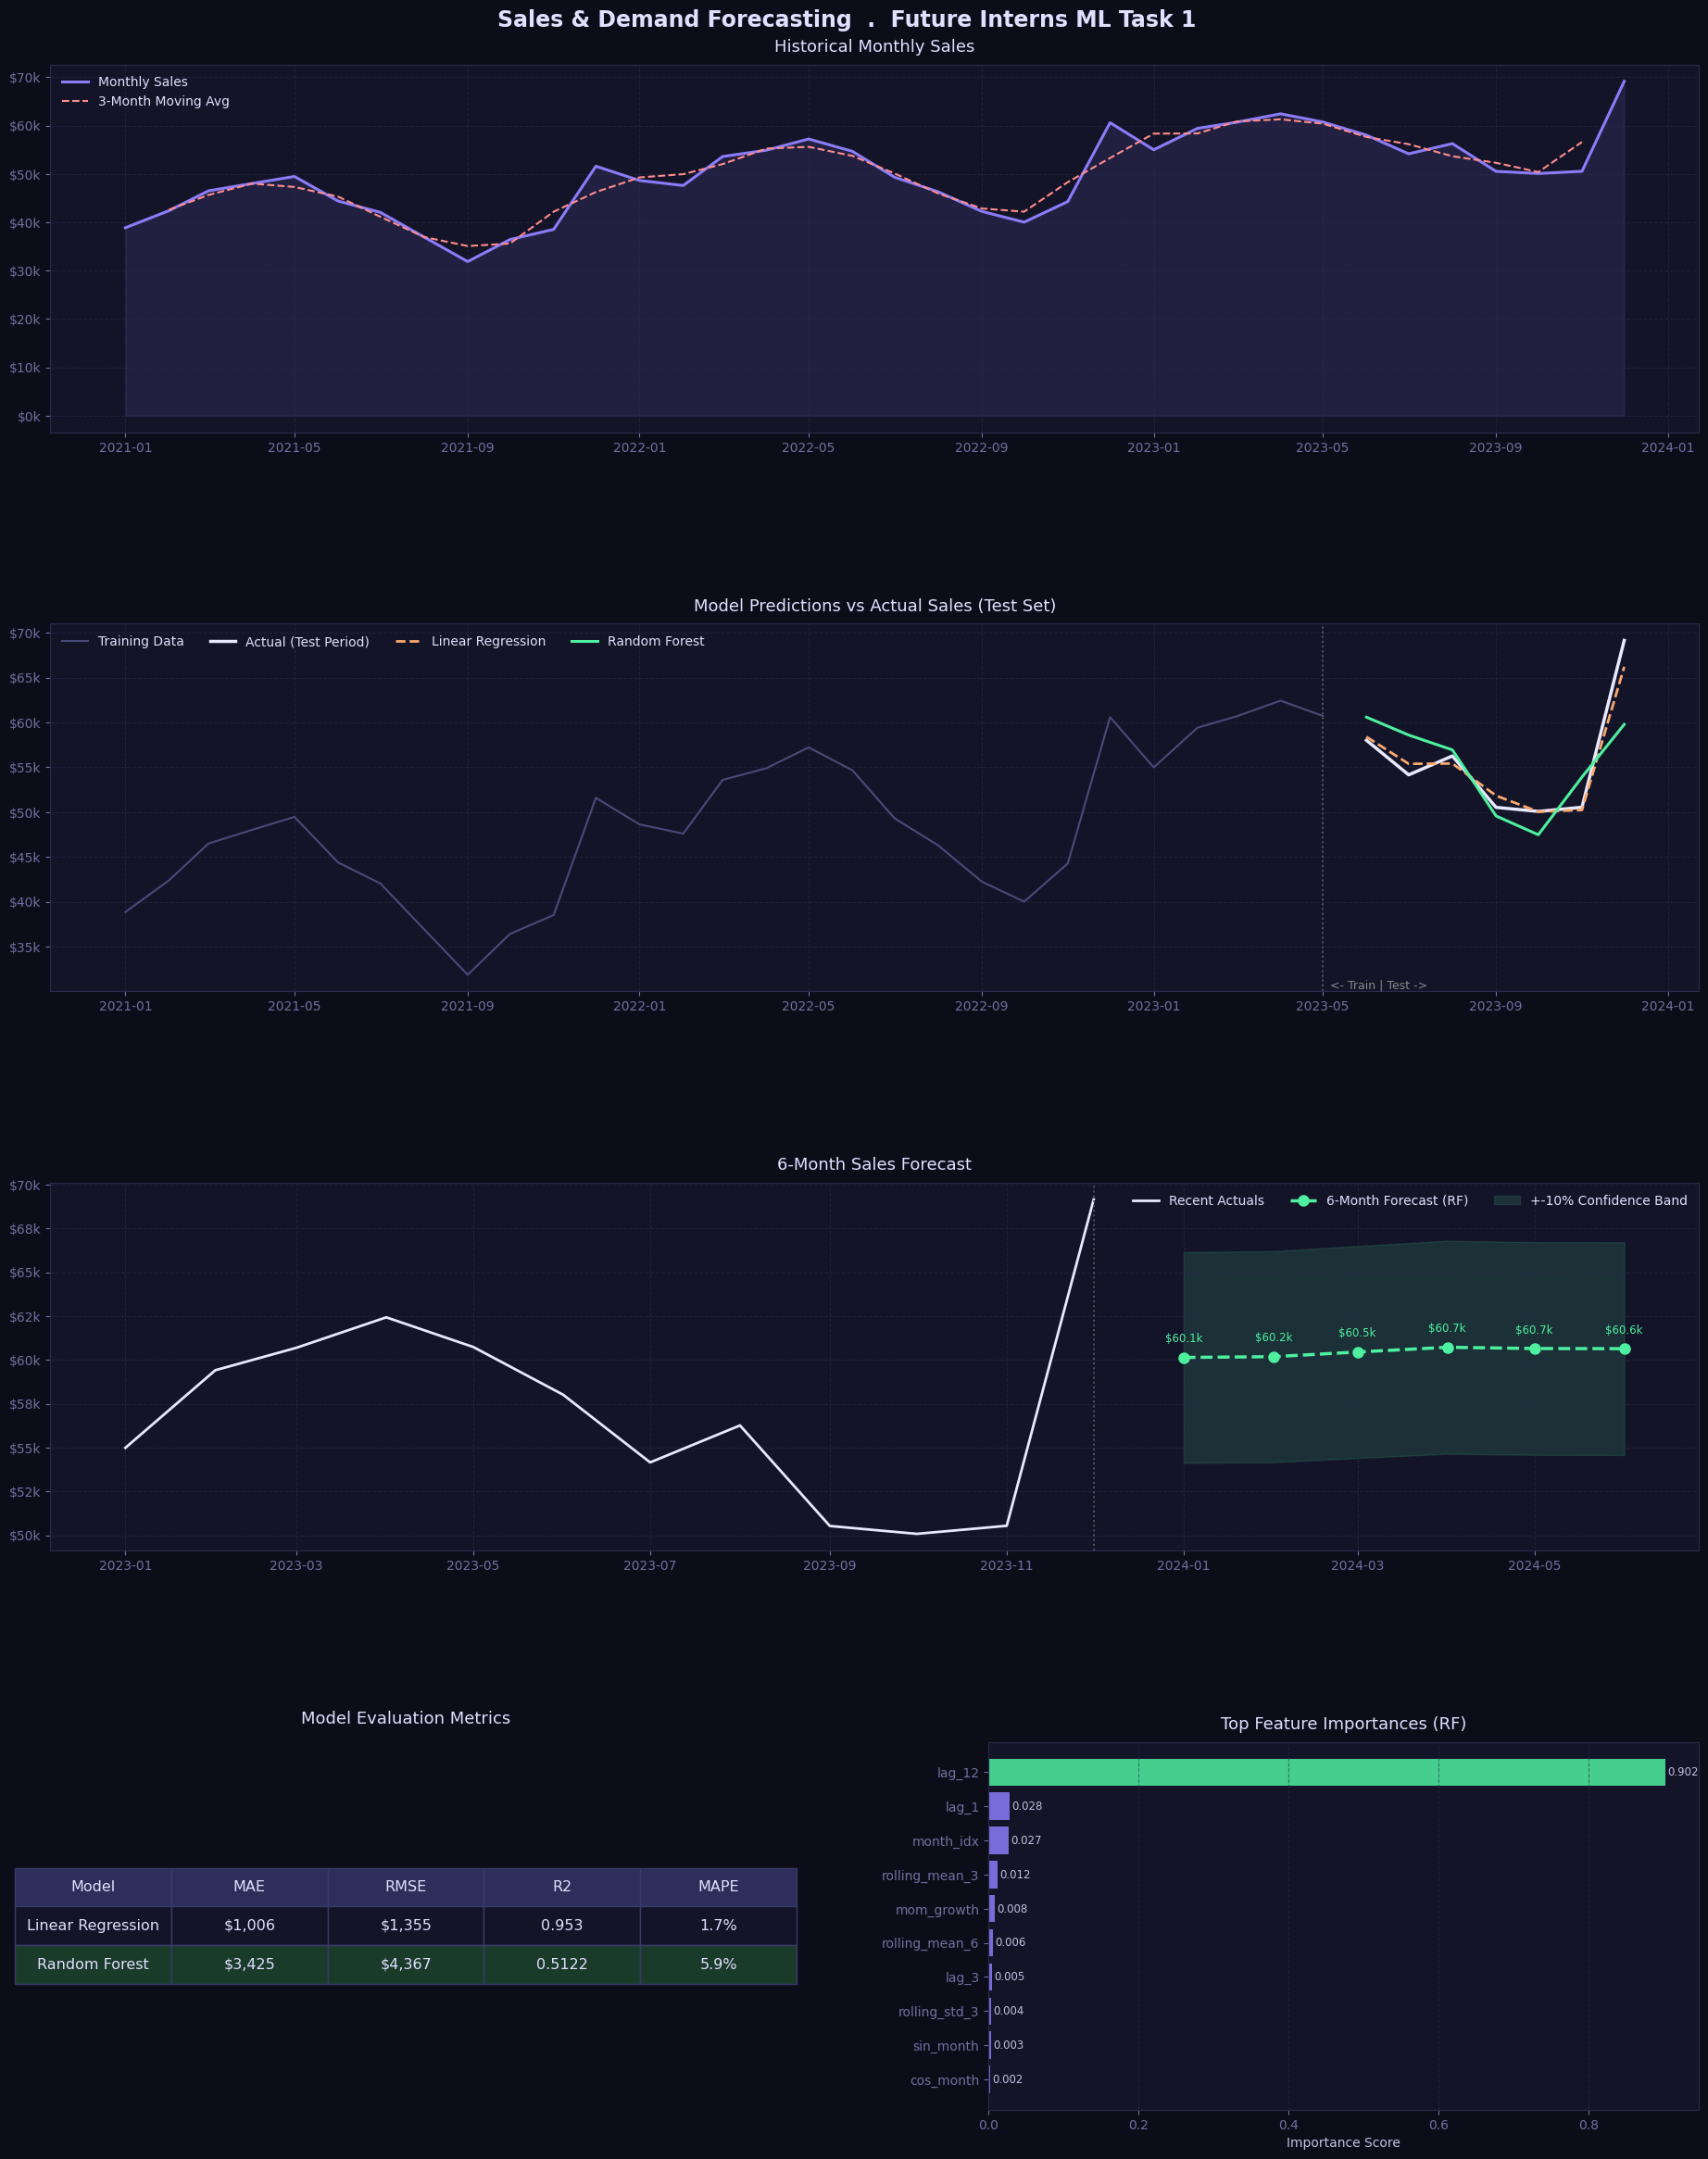

  Forecast data saved -> FUTURE_ML_01_forecast.csv

All done! Push to GitHub as FUTURE_ML_01



In [1]:
import warnings
warnings.filterwarnings("ignore")

import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler


plt.rcParams.update({
    "figure.facecolor": "#0d0d1a",
    "axes.facecolor":   "#141428",
    "axes.edgecolor":   "#2a2a4a",
    "axes.labelcolor":  "#c0c0e0",
    "xtick.color":      "#7070a0",
    "ytick.color":      "#7070a0",
    "text.color":       "#e0e0ff",
    "grid.color":       "#2a2a4a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.55,
})

COL_ACTUAL   = "#8b7cf8"
COL_LR       = "#f8a96e"
COL_RF       = "#4ef0a0"
COL_FORECAST = "#4ef0a0"


DATASET_URL = (
    "https://raw.githubusercontent.com/dsrscientist/"
    "dataset1/master/superstore.csv"
)

def load_data():
    """
    Downloads the Superstore CSV. If the internet is unavailable,
    falls back to a synthetic dataset so the script still runs.
    """
    print("  Downloading Superstore dataset ...")
    try:
        resp = requests.get(DATASET_URL, timeout=15)
        resp.raise_for_status()
        df = pd.read_csv(io.StringIO(resp.text), encoding="latin-1")
        print(f"  Loaded {len(df):,} rows from online dataset.")
        return df
    except Exception as e:
        print(f"  Could not download ({e}). Using synthetic fallback.")
        return _synthetic_fallback()


def _synthetic_fallback():
    """
    Creates 4 years of realistic synthetic monthly sales so the
    script works even without internet access.
    """
    np.random.seed(0)
    dates = pd.date_range("2020-01-01", periods=48, freq="MS")
    trend = np.linspace(30_000, 60_000, 48)
    seas  = 8_000 * np.sin(2 * np.pi * (dates.month - 1) / 12)
    holiday = np.where(dates.month == 12, 12_000, 0)
    noise = np.random.normal(0, 1_500, 48)
    sales = np.maximum(trend + seas + holiday + noise, 5_000)
    rows = []
    for d, s in zip(dates, sales):
        n = np.random.randint(20, 80)
        for _ in range(n):
            rows.append({
                "Order Date": d + pd.Timedelta(days=np.random.randint(0, 28)),
                "Sales":      s / n + np.random.normal(0, 10),
                "Category":   np.random.choice(["Furniture","Technology","Office Supplies"]),
                "Region":     np.random.choice(["East","West","Central","South"]),
            })
    return pd.DataFrame(rows)


def clean_and_aggregate(df):
    """
    WHAT THIS FUNCTION DOES (step by step):

    1. Normalise column names
       The raw CSV might have "Order Date" or "order_date".
       We lowercase and strip spaces so our code always works.

    2. Parse dates
       The date column arrives as a STRING like "2021-03-15".
       We convert it to a proper Python datetime so we can do
       date arithmetic (e.g. "give me all rows in March 2021").

    3. Drop missing values
       Any row where Sales or Order Date is missing is useless --
       we drop it rather than guessing.

    4. Remove negative sales
       Returns are sometimes negative. For forecasting we only
       want genuine forward sales.

    5. Resample to monthly totals
       ML models need consistent time intervals. We group every
       transaction in the same month together and sum the Sales.
       Daily -> Monthly makes the pattern cleaner and easier to learn.
    """
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    date_col  = next((c for c in df.columns if "order" in c and "date" in c), None)
    sales_col = next((c for c in df.columns if "sales" in c), None)

    if date_col is None or sales_col is None:
        raise ValueError("Could not find 'order date' or 'sales' columns.")

    df[date_col]  = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")
    df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")

    df = df.dropna(subset=[date_col, sales_col])
    df = df[df[sales_col] > 0]

    monthly = (
        df.set_index(date_col)[sales_col]
          .resample("MS")
          .sum()
          .reset_index()
    )
    monthly.columns = ["date", "sales"]

    monthly = monthly[monthly["sales"] > 100].reset_index(drop=True)

    print(f"  Date range     : {monthly['date'].min().date()} -> "
          f"{monthly['date'].max().date()}")
    print(f"  Monthly periods: {len(monthly)}")
    return monthly


FEATURES = [
    "month_idx",
    "sin_month", "cos_month",
    "quarter", "is_q4", "is_december",
    "lag_1", "lag_3", "lag_6", "lag_12",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3",
    "mom_growth",
]

def engineer_features(df):
    df = df.copy()

    df["month"]     = df["date"].dt.month
    df["quarter"]   = df["date"].dt.quarter
    df["year"]      = df["date"].dt.year
    df["month_idx"] = np.arange(len(df))

    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)

    df["is_q4"]       = (df["quarter"] == 4).astype(int)
    df["is_december"] = (df["month"] == 12).astype(int)

    df["lag_1"]  = df["sales"].shift(1)
    df["lag_3"]  = df["sales"].shift(3)
    df["lag_6"]  = df["sales"].shift(6)
    df["lag_12"] = df["sales"].shift(12)

    df["rolling_mean_3"] = df["sales"].shift(1).rolling(window=3).mean()
    df["rolling_mean_6"] = df["sales"].shift(1).rolling(window=6).mean()
    df["rolling_std_3"]  = df["sales"].shift(1).rolling(window=3).std()

    df["mom_growth"] = df["sales"].pct_change()

    df = df.dropna().reset_index(drop=True)
    print(f"  Features engineered. Usable rows: {len(df)}")
    return df


def split_and_train(df):
    X = df[FEATURES]
    y = df["sales"]

    n_test = min(12, max(6, len(df) // 5))
    split  = len(df) - n_test

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    dates_test      = df["date"].iloc[split:]

    print(f"  Train: {split} months  |  Test: {n_test} months")

    scaler   = StandardScaler()
    Xs_train = scaler.fit_transform(X_train)
    Xs_test  = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(Xs_train, y_train)       # "learn" the weights
    lr_pred = lr.predict(Xs_test)   # "predict" on unseen test data

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    return {
        "df":          df,
        "X_train":     X_train,
        "X_test":      X_test,
        "y_train":     y_train,
        "y_test":      y_test,
        "dates_train": df["date"].iloc[:split],
        "dates_test":  dates_test,
        "lr_pred":     lr_pred,
        "rf_pred":     rf_pred,
        "lr_model":    lr,
        "rf_model":    rf,
        "scaler":      scaler,
    }


def compute_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred))
                           / np.array(y_true))) * 100
    return {
        "Model": model_name,
        "MAE":   f"${mean_absolute_error(y_true, y_pred):,.0f}",
        "RMSE":  f"${rmse:,.0f}",
        "R2":    round(r2_score(y_true, y_pred), 4),
        "MAPE":  f"{mape:.1f}%",
    }


def forecast_future(df, rf_model, n_months=6):
    history = list(df["sales"].values)
    last_dt = df["date"].iloc[-1]
    rows    = []

    for i in range(1, n_months + 1):
        next_dt   = last_dt + pd.DateOffset(months=i)
        month_idx = df["month_idx"].max() + i
        m         = next_dt.month

        def lag(n):
            return history[-n] if len(history) >= n else np.mean(history)

        def roll_mean(n):
            return np.mean(history[-n:]) if len(history) >= n else np.mean(history)

        def roll_std(n):
            return np.std(history[-n:])  if len(history) >= n else 0

        mom_g = (history[-1] - history[-2]) / history[-2] if len(history) >= 2 else 0

        feature_row = {
            "month_idx":      month_idx,
            "sin_month":      np.sin(2 * np.pi * m / 12),
            "cos_month":      np.cos(2 * np.pi * m / 12),
            "quarter":        next_dt.quarter,
            "is_q4":          int(next_dt.quarter == 4),
            "is_december":    int(m == 12),
            "lag_1":          lag(1),
            "lag_3":          lag(3),
            "lag_6":          lag(6),
            "lag_12":         lag(12),
            "rolling_mean_3": roll_mean(3),
            "rolling_mean_6": roll_mean(6),
            "rolling_std_3":  roll_std(3),
            "mom_growth":     mom_g,
        }

        X_row = pd.DataFrame([feature_row])[FEATURES]
        pred  = rf_model.predict(X_row)[0]
        history.append(pred)

        rows.append({
            "date":     next_dt,
            "forecast": round(pred, 2),
            "low":      round(pred * 0.90, 2),
            "high":     round(pred * 1.10, 2),
        })

    return pd.DataFrame(rows)


def fmt_k(x, _):
    """Formats axis labels as $12k, $34k etc."""
    return f"${x/1000:.0f}k"


def plot_dashboard(df, res, metrics_list, forecast_df):
    fig = plt.figure(figsize=(20, 24))
    fig.suptitle(
        "Sales & Demand Forecasting  .  Future Interns ML Task 1",
        fontsize=17, fontweight="bold", color="#e0e0ff", y=0.985,
    )

    gs = fig.add_gridspec(
        4, 2,
        hspace=0.52, wspace=0.32,
        left=0.07, right=0.96,
        top=0.96, bottom=0.04,
    )

    ax0 = fig.add_subplot(gs[0, :])
    ax0.fill_between(df["date"], df["sales"], alpha=0.12, color=COL_ACTUAL)
    ax0.plot(df["date"], df["sales"],
             color=COL_ACTUAL, lw=2.2, label="Monthly Sales")
    df_plot = df.copy()
    df_plot["smooth"] = df["sales"].rolling(3, center=True).mean()
    ax0.plot(df_plot["date"], df_plot["smooth"],
             color="#ff8c8c", lw=1.5, linestyle="--", label="3-Month Moving Avg")
    ax0.set_title("Historical Monthly Sales", fontsize=13, pad=10)
    ax0.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax0.legend(framealpha=0, fontsize=10)
    ax0.grid(True)

    ax1 = fig.add_subplot(gs[1, :])
    ax1.plot(res["dates_train"], res["y_train"],
             color="#4a4a7a", lw=1.5, label="Training Data")
    ax1.plot(res["dates_test"], res["y_test"],
             color="#e8e8ff", lw=2.5, label="Actual (Test Period)")
    ax1.plot(res["dates_test"], res["lr_pred"],
             color=COL_LR, lw=2, linestyle="--", label="Linear Regression")
    ax1.plot(res["dates_test"], res["rf_pred"],
             color=COL_RF, lw=2.2, label="Random Forest")
    split_date = res["dates_train"].iloc[-1]
    ax1.axvline(split_date, color="#555", linestyle=":", lw=1.4)
    ax1.text(split_date, ax1.get_ylim()[0],
             "  <- Train | Test ->", color="#888", fontsize=9, va="bottom")
    ax1.set_title("Model Predictions vs Actual Sales (Test Set)", fontsize=13, pad=10)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax1.legend(framealpha=0, ncol=4, fontsize=10)
    ax1.grid(True)

    ax2 = fig.add_subplot(gs[2, :])
    last_n = df.iloc[-12:]
    ax2.plot(last_n["date"], last_n["sales"],
             color="#e8e8ff", lw=2, label="Recent Actuals")
    ax2.plot(forecast_df["date"], forecast_df["forecast"],
             color=COL_FORECAST, lw=2.5, linestyle="--",
             marker="o", ms=8, label="6-Month Forecast (RF)")
    ax2.fill_between(
        forecast_df["date"],
        forecast_df["low"], forecast_df["high"],
        color=COL_FORECAST, alpha=0.13, label="+-10% Confidence Band",
    )
    for _, row in forecast_df.iterrows():
        ax2.annotate(
            f"${row['forecast']/1000:.1f}k",
            xy=(row["date"], row["forecast"]),
            xytext=(0, 12), textcoords="offset points",
            ha="center", fontsize=8.5, color=COL_FORECAST,
        )
    ax2.axvline(last_n["date"].iloc[-1], color="#555", linestyle=":", lw=1.4)
    ax2.set_title("6-Month Sales Forecast", fontsize=13, pad=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax2.legend(framealpha=0, ncol=3, fontsize=10)
    ax2.grid(True)

    ax3 = fig.add_subplot(gs[3, 0])
    ax3.axis("off")
    metrics_df = pd.DataFrame(metrics_list)
    tbl = ax3.table(
        cellText  = metrics_df.values.tolist(),
        colLabels = list(metrics_df.columns),
        loc       = "center",
        cellLoc   = "center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11.5)
    tbl.scale(1.1, 2.5)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#2e2e5a")
        elif r == 2:
            cell.set_facecolor("#1a3a2a")
        else:
            cell.set_facecolor("#141428")
        cell.set_edgecolor("#3a3a6a")
        cell.set_text_props(color="#e0e0ff")
    ax3.set_title("Model Evaluation Metrics", fontsize=13, pad=14)

    ax4 = fig.add_subplot(gs[3, 1])
    importances = (
        pd.Series(res["rf_model"].feature_importances_, index=FEATURES)
        .sort_values(ascending=True)
        .tail(10)
    )
    colors = [COL_RF if v == importances.max() else COL_ACTUAL for v in importances.values]
    bars = ax4.barh(importances.index, importances.values, color=colors, alpha=0.85)
    for bar, val in zip(bars, importances.values):
        ax4.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=8.5, color="#c0c0e0")
    ax4.set_title("Top Feature Importances (RF)", fontsize=13, pad=10)
    ax4.set_xlabel("Importance Score")
    ax4.grid(axis="x")

    outfile = "FUTURE_ML_01_dashboard.png"
    plt.savefig(outfile, dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
    print(f"\n  Dashboard saved -> {outfile}")
    plt.show()


def print_business_summary(df, metrics_list, forecast_df):
    best   = sorted(metrics_list, key=lambda x: float(x["R2"]), reverse=True)[0]
    peak   = forecast_df.loc[forecast_df["forecast"].idxmax()]
    trough = forecast_df.loc[forecast_df["forecast"].idxmin()]
    total  = forecast_df["forecast"].sum()
    change = ((forecast_df["forecast"].iloc[-1] / forecast_df["forecast"].iloc[0]) - 1) * 100

    sep = "=" * 64
    print(f"\n{sep}")
    print("  BUSINESS INTELLIGENCE REPORT  --  FUTURE INTERNS ML TASK 1")
    print(sep)
    print(f"\n  Dataset period  : {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"  Monthly records : {len(df)}")
    print(f"  Avg monthly rev : ${df['sales'].mean():,.0f}")
    print(f"  Best month ever : {df.loc[df['sales'].idxmax(),'date'].strftime('%b %Y')}"
          f"  (${df['sales'].max():,.0f})")
    print(f"\n  -- Model Scores " + "-"*46)
    for m in metrics_list:
        marker = "  BEST" if m["Model"] == best["Model"] else ""
        print(f"  {m['Model']:<22}  MAE={m['MAE']}  RMSE={m['RMSE']}  "
              f"R2={m['R2']}  MAPE={m['MAPE']}{marker}")
    print(f"\n  Best model: {best['Model']} (R2 = {best['R2']})")
    print(f"\n  -- 6-Month Forecast " + "-"*43)
    for _, r in forecast_df.iterrows():
        bar = "#" * int(r["forecast"] / (df["sales"].max() / 25))
        print(f"  {r['date'].strftime('%b %Y')}  ${r['forecast']:>10,.0f}  {bar}")
    print(f"\n  Projected 6-month revenue : ${total:,.0f}")
    print(f"  Peak forecast month       : {peak['date'].strftime('%b %Y')}  "
          f"(${peak['forecast']:,.0f})")
    print(f"  Lowest forecast month     : {trough['date'].strftime('%b %Y')}  "
          f"(${trough['forecast']:,.0f})")
    print(f"  Trend direction           : {change:+.1f}% over 6 months")
    print(f"\n  -- Business Recommendations " + "-"*35)
    print(f"  -> Stock up inventory BEFORE {peak['date'].strftime('%B %Y')} (peak demand).")
    print(f"  -> Reduce reorder quantities in {trough['date'].strftime('%B %Y')} (dip).")
    if change > 0:
        print(f"  -> Upward trend (+{change:.1f}%): consider expanding SKUs or staff.")
    else:
        print(f"  -> Downward trend ({change:.1f}%): tighten costs and review promotions.")
    print(f"  -> Forecast band +-10%: budget conservatively using lower bound.")
    print(f"\n{sep}\n")


if __name__ == "__main__":
    print("\n" + "="*64)
    print("  FUTURE INTERNS -- ML Task 1: Sales & Demand Forecasting")
    print("="*64 + "\n")

    print("STEP 1/6 -- Loading & cleaning data")
    raw     = load_data()
    monthly = clean_and_aggregate(raw)

    print("\nSTEP 2/6 -- Engineering features")
    feat_df = engineer_features(monthly)

    if len(feat_df) < 24:
        print("Not enough data months for reliable modelling. Try a larger dataset.")
        exit(1)

    print("\nSTEP 3/6 -- Training models")
    res = split_and_train(feat_df)

    print("\nSTEP 4/6 -- Evaluating models")
    metrics_list = [
        compute_metrics(res["y_test"], res["lr_pred"], "Linear Regression"),
        compute_metrics(res["y_test"], res["rf_pred"], "Random Forest"),
    ]

    print("\nSTEP 5/6 -- Forecasting next 6 months")
    forecast_df = forecast_future(feat_df, res["rf_model"], n_months=6)

    print("\nSTEP 6/6 -- Generating outputs")
    print_business_summary(feat_df, metrics_list, forecast_df)
    plot_dashboard(feat_df, res, metrics_list, forecast_df)

    forecast_df.to_csv("FUTURE_ML_01_forecast.csv", index=False)
    print("  Forecast data saved -> FUTURE_ML_01_forecast.csv")
